# Use this code for testing the random forest model

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import numpy as np
from Random_forest.RandomForest import RandomForest
import os
from Random_forest.RF_preprocessing import load_samples, preprocess_samples
from sklearn.metrics import classification_report
import pickle
import seaborn as sns

## Test data preprocessing

In [2]:
# Replace the path to the test data if you 
samples, labels = load_samples("training_data")
X, y = preprocess_samples(samples), np.array(labels)
print(X.shape,y.shape)
print(max([len(s) for s in samples]))

(1000, 512) (1000,)
222


## Load the model

In [3]:
trained_model_dir = os.path.join("./trained_models")
model_name = "RF_classifier.pkl"
model_path = os.path.join(trained_model_dir, model_name)

with open(model_path, "rb") as f: 
    RF_classifier_model:RandomForest = pickle.load(f)

## Test with it

In [4]:
# Extract a random test set form training data.
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# For external test set just feed the X and y directly to the model
# X_test = X
# y_test = y

# Test model performance
y_pred = RF_classifier_model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.95      0.95      0.95        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       0.95      0.95      0.95        20
           5       0.95      1.00      0.98        20
           6       1.00      0.95      0.97        20
           7       1.00      0.95      0.97        20
           8       1.00      1.00      1.00        20
           9       0.95      0.95      0.95        20

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



<Axes: >

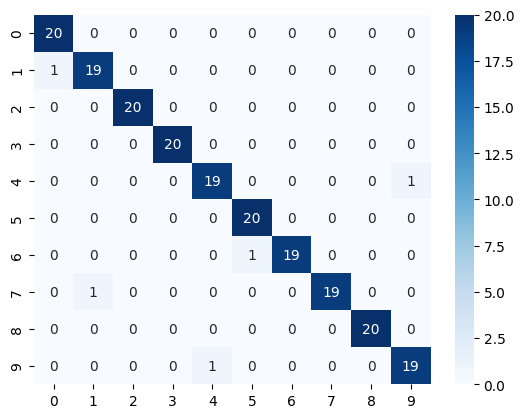

In [5]:
confusion_matrix = np.zeros((10, 10), dtype=int)

for i, j in zip(y_test, y_pred): 
    confusion_matrix[i, j] += 1

sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))